##**Desafíos en el NLP**

**Desafios**
- Trabajar con texto desordenado y sin procesar.
- Implementar preprocesamiento eficiente (tokenización, y eliminación de ruido).
- Diseñar un modelo que maneje problemas como ambigüedad semántica y desbalanceo de datos.
- Evaluar y mejorar el rendimiento del modelo.




**Dataset**

Usaremos un dataset de análisis de sentimientos de Twitter con texto real y ruido (errores, emojis, etc.). Puedes descargarlo aquí:

In [1]:
!wget -nc https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv


--2026-01-29 08:13:00--  https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3103165 (3.0M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]   2.96M  --.-KB/s    in 0.02s   

2026-01-29 08:13:00 (172 MB/s) - ‘train.csv’ saved [3103165/3103165]



**Instalación de librerías necesarias**

In [2]:
# --- Instalación de librerías necesarias ---
!pip install wordcloud scikit-learn matplotlib pandas seaborn

# --- Importar librerías ---
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# --- Paso 1: Descargar y cargar el dataset ---
!wget -nc https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv
data = pd.read_csv("train.csv")

# Ver las primeras filas del dataset
data.head()


File ‘train.csv’ already there; not retrieving.



,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


**Preprocesar el texto**

Vamos a eliminar carácteres que a nuestro modelo puede llevar a equivoco.

- Menciones como @usuario.
- URLs completas que comiencen con http:// o https://.
- URLs con www. al inicio.

Desglose de la Expresión Regular

    @\w+
        @: Busca el símbolo @.
        \w+: Encuentra una palabra alfanuméricas después del @. Esto coincide con menciones típicas en redes sociales, como @usuario.
        Ejemplo:
            En el texto Hola @juan, ¿cómo estás?, coincidirá con @juan.

    https?://\S+
        https?: Busca http o https (la s es opcional debido al signo de interrogación ?).
        ://: Busca los dos puntos y las barras (://), típicos en URLs.
        \S+: Coincide con uno o más caracteres que no sean espacios en blanco (todo lo que compone el resto de la URL).
        Ejemplo:
            En el texto Visita https://example.com para más información, coincidirá con https://example.com.

    www\.\S+
        www\.: Busca cadenas que comiencen con www..
        \S+: Coincide con uno o más caracteres que no sean espacios en blanco (el resto de la URL).
        Ejemplo:
            En el texto Mira www.example.com ahora, coincidirá con www.example.com.

In [3]:
# --- Paso 2: Preprocesar el texto ---
# Función para limpiar texto desordenado
def clean_text(text):
    text = text.lower()  # Convertir a minúsculas
    text = re.sub(r'@\w+|https?://\S+|www\.\S+', '', text)  # Quitar menciones y URLs
    text = re.sub(r'[^a-z\s]', '', text)  # Quitar caracteres especiales
    return text

# Aplicar limpieza al texto
data['cleaned_text'] = data['tweet'].apply(clean_text)

# Verificar los datos preprocesados
data[['tweet', 'cleaned_text']].head()


,tweet,cleaned_text
0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they...
2,bihday your majesty,bihday your majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in u...
4,factsguide: society now #motivation,factsguide society now motivation


**Visualizar distribución de clases**

In [4]:
# --- Paso 3: Visualizar distribución de clases ---
# Revisar la distribución de clases
print(data['label'].value_counts())  # 0 = Negativo, 1 = Positivo

label
0    29720
1     2242
Name: count, dtype: int64


**Dividir datos y vectorizar**

TfidfVectorizer(max_features=5000):

- Convierte texto en una matriz numérica de características utilizando la técnica TF-IDF.
- max_features=5000: Limita el vocabulario a las 5000 palabras más frecuentes en el corpus, lo que reduce la dimensionalidad.
- stop_words='english': Excluye palabras comunes en inglés que no aportan significado, como "the", "and", "is", etc.

In [5]:
# --- Paso 4: Dividir datos y vectorizar ---
# Dividir los datos en entrenamiento y prueba
X = data['cleaned_text']
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorizar texto con TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


**Entrenar un modelo básico**

In [6]:
# --- Paso 5: Entrenar un modelo básico ---
# Usar regresión logística
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Evaluar el modelo
y_pred = model.predict(X_test_vec)

print("Reporte de clasificación:\n", classification_report(y_test, y_pred))


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.92      0.33      0.48       456

    accuracy                           0.95      6393
   macro avg       0.94      0.66      0.73      6393
weighted avg       0.95      0.95      0.94      6393



**Visualización con nubes de palabras**

Reporte de Clasificación: Explicación Detallada

El reporte de clasificación muestra las métricas de evaluación de un modelo de clasificación, proporcionando información sobre su rendimiento en términos de precisión, cobertura (recall), F1-score y soporte para cada clase.
1. Clases Individuales

La evaluación se realiza para cada clase en el conjunto de datos. En este caso, hay dos clases:

    Clase 0: Representa una categoría Tweet negativo / no discriminatorio / no odio
    Clase 1: Representa otra categoría tweets de odio/racismo/sexismo

Métricas por Clase

    Precision: Proporción de predicciones correctas dentro de todas las predicciones hechas para esa clase.
    Recall: Proporción de ejemplos reales de una clase que fueron correctamente identificados por el modelo.
    F1-Score: Media armónica entre precisión y recall, equilibrando ambas métricas.
    Support: Número real de muestras de esa clase en el conjunto de prueba.

Interpretación de las Clases

               precision    recall  f1-score   support

           0       0.95      1.00      0.97      5937
           1       0.92      0.33      0.48       456

Clase 0:

    Precision: 0.95 → El 95% de las veces que el modelo predijo la clase 0, fue correcto.
    Recall: 1.00 → El modelo identificó correctamente el 100% de los ejemplos reales de la clase 0.
    F1-Score: 0.97 → Buen balance entre precisión y recall.
    Support: 5937 → Hay 5937 muestras reales de la clase 0.

Clase 1:

    Precision: 0.92 → El 92% de las veces que el modelo predijo la clase 1, fue correcto.
    Recall: 0.33 → Solo el 33% de los ejemplos reales de la clase 1 fueron identificados correctamente.
    F1-Score: 0.48 → El balance entre precisión y recall es bajo debido al pobre recall.
    Support: 456 → Hay 456 muestras reales de la clase 1.

2. Métricas Globales
Accuracy (Precisión Global)

    accuracy                           0.95      6393

    Accuracy: El 95% de todas las muestras fueron clasificadas correctamente.
    Total de Muestras: 6393.

Aunque la precisión global es alta, esto puede ser engañoso si el modelo clasifica mal las clases minoritarias (como ocurre aquí con la clase 1).
Promedios Macro y Ponderados

    macro avg       0.94      0.66      0.73      6393
    weighted avg    0.95      0.95      0.94      6393

Macro Average (Promedio Macro):

    Calcula las métricas promedio de manera uniforme para todas las clases (sin importar su tamaño).
    Precisión (0.94): Promedio entre la precisión de las clases 0 y 1.
    Recall (0.66): Promedio entre el recall de las clases 0 y 1.
    F1-Score (0.73): Promedio entre el F1-score de las clases 0 y 1.
    Refleja el rendimiento del modelo en cada clase por igual, sin dar prioridad a las clases grandes.

Weighted Average (Promedio Ponderado):

    Calcula un promedio ponderado según el tamaño (soporte) de cada clase.
    Weighted Recall (0.95): Alto porque la clase mayoritaria (0) tiene buen recall y domina el dataset.
    Da una imagen general del rendimiento del modelo, pero puede ocultar problemas en clases minoritarias.

Interpretación General

    Clase 0 (Mayoritaria):
        El modelo funciona excelentemente, con alta precisión, recall y F1-score.

    Clase 1 (Minoritaria):
        Aunque la precisión es buena (0.92), el recall es muy bajo (0.33), lo que indica que el modelo tiene dificultades para identificar correctamente ejemplos de la clase 1.

Conclusión

Aunque el accuracy global es alto (0.95), el modelo está desbalanceado: clasifica bien la clase mayoritaria (0) pero tiene problemas con la clase minoritaria (1).

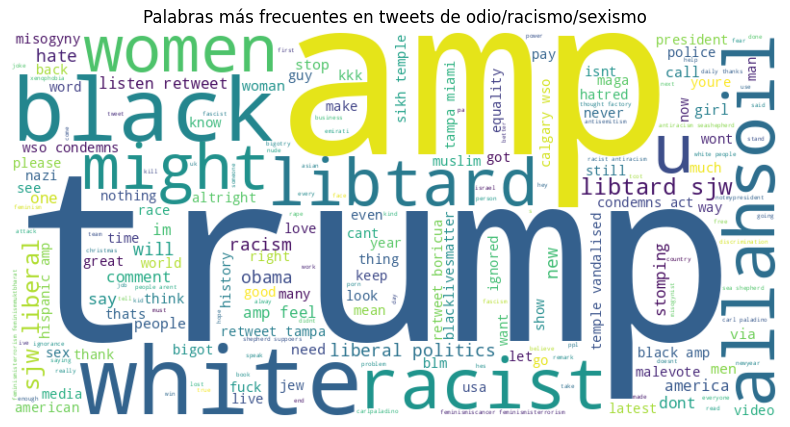

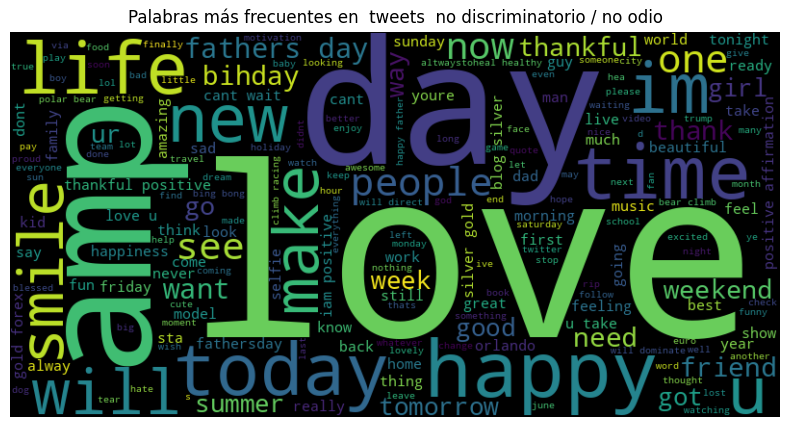

In [7]:
# --- Paso 6: Visualización con nubes de palabras ---
# Generar nube de palabras para sentimientos positivos
positive_text = " ".join(data[data['label'] == 1]['cleaned_text'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes en tweets de odio/racismo/sexismo")
plt.show()

# Generar nube de palabras para sentimientos negativos
negative_text = " ".join(data[data['label'] == 0]['cleaned_text'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Palabras más frecuentes en  tweets  no discriminatorio / no odio")
plt.show()


**Ejercicio 1  Resolver el desbalance de clases**

Se requiere que balanceis las clases y analizar si tenemos mejor o peor desempeño


In [9]:
from sklearn.utils import resample

# 1. Separar las clases
df_majority = data[data.label == 0]
df_minority = data[data.label == 1]

# 2. Aplicar Oversampling a la clase minoritaria
df_minority_upsampled = resample(df_minority,
                                 replace=True,     # Muestreo con reemplazo
                                 n_samples=len(df_majority),    # Igualar a la clase mayoritaria
                                 random_state=42) # Para reproducibilidad

# 3. Combinar de nuevo
data_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Nuevos conteos de clase:")
print(data_balanced.label.value_counts())

Nuevos conteos de clase:
label
0    29720
1    29720
Name: count, dtype: int64


In [10]:
# --- Re-entrenamiento del modelo con datos balanceados ---

# Limpieza (usamos la función existente)
data_balanced['cleaned_text'] = data_balanced['tweet'].apply(clean_text)

# División y Vectorización
X_bal = data_balanced['cleaned_text']
y_bal = data_balanced['label']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42)

vectorizer_b = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec_b = vectorizer_b.fit_transform(X_train_b)
X_test_vec_b = vectorizer_b.transform(X_test_b)

# Entrenamiento
model_b = LogisticRegression(max_iter=1000)
model_b.fit(X_train_vec_b, y_train_b)

# Predicción
y_pred_b = model_b.predict(X_test_vec_b)

print(classification_report(y_test_b, y_pred_b))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      5880
           1       0.94      0.98      0.96      6008

    accuracy                           0.96     11888
   macro avg       0.96      0.96      0.96     11888
weighted avg       0.96      0.96      0.96     11888



**Ejercicio 2  Preprocesamiento**
La aparición del token “amp” en ambas clases de sentimiento no está relacionada con el contenido semántico de los tweets. Este token procede de una decodificación incorrecta de entidades HTML (&amp;) presentes en los textos originales de Twitter.
Su presencia introduce ruido léxico que afecta negativamente tanto a la visualización (WordCloud) como al rendimiento de modelos de PLN.


In [11]:
# Definimos la función que elimina 'amp'
def clean_text_v2(text):
    text = text.lower()
    # 1. Eliminar específicamente el código HTML '&amp;' y la palabra suelta 'amp'
    # Se reemplaza por un espacio para evitar unir palabras accidentalmente
    text = re.sub(r'&amp;', ' ', text)
    text = re.sub(r'\bamp\b', ' ', text)

    # 2. El resto de la limpieza estándar que ya tenías
    text = re.sub(r'@\w+|https?://\S+|www\.\S+', '', text) # URLs y menciones
    text = re.sub(r'[^a-z\s]', '', text) # Solo letras
    return text

# Aplicamos esta nueva limpieza al dataset original
data['cleaned_text_v2'] = data['tweet'].apply(clean_text_v2)

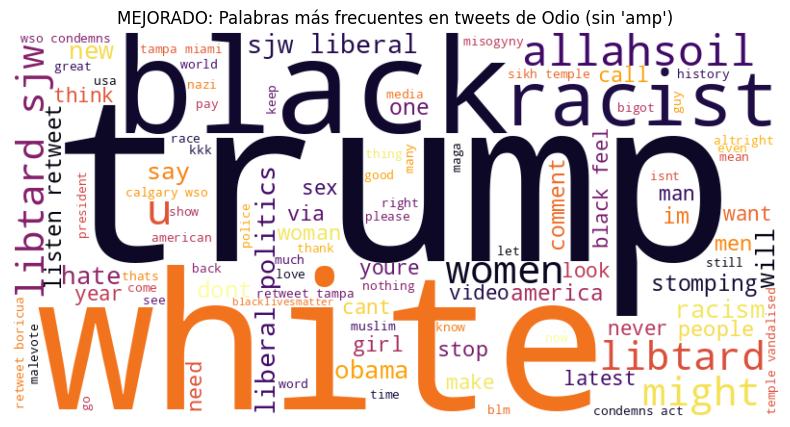

In [13]:
# --- GENERACIÓN DE NUBES DE PALABRAS MEJORADAS ---

# 1. Nube para tweets de Odio/Racismo/Sexismo (Label = 1)
toxic_text_v2 = " ".join(data[data['label'] == 1]['cleaned_text_v2'])

# Usé un mapa de color 'inferno' para darle un tono más agresivo a esta nube
wordcloud_toxic = WordCloud(width=800, height=400, background_color='white', colormap='inferno', max_words=100).generate(toxic_text_v2)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_toxic, interpolation='bilinear')
plt.axis('off')
plt.title("MEJORADO: Palabras más frecuentes en tweets de Odio (sin 'amp')")
plt.show()

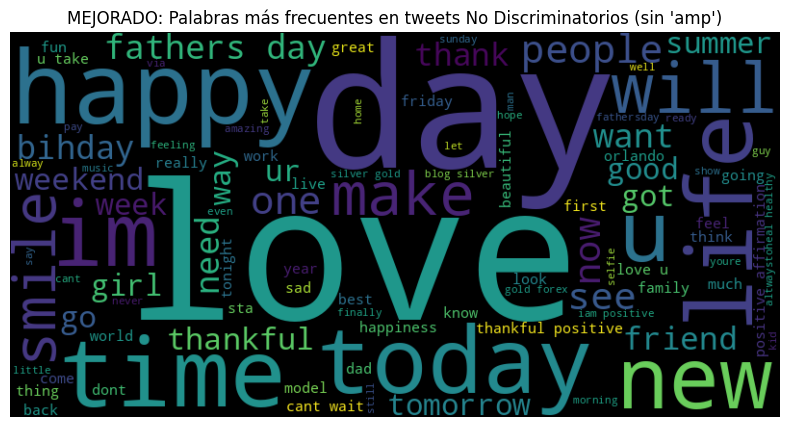

In [14]:
# 2. Nube para tweets No Discriminatorios (Label = 0)
non_toxic_text_v2 = " ".join(data[data['label'] == 0]['cleaned_text_v2'])

# Usé un mapa de color 'viridis' para esta nube
wordcloud_non_toxic = WordCloud(width=800, height=400, background_color='black', colormap='viridis', max_words=100).generate(non_toxic_text_v2)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_non_toxic, interpolation='bilinear')
plt.axis('off')
plt.title("MEJORADO: Palabras más frecuentes en tweets No Discriminatorios (sin 'amp')")
plt.show()